In [27]:
print("reck98")
!(which python)
!(python --version)

reck98
/run/media/reck98/Others/Development/ML_NLP_DL/dl/.venv/bin/python
Python 3.12.12


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense


from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical


from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


from pathlib import Path as FilePath

In [29]:
TEST_DATA_PATH = FilePath("/run/media/reck98/Others/Development/ML_NLP_DL/dl/cnn/datasets/mnist_test.csv")
TRAIN_DATA_PATH = FilePath("/run/media/reck98/Others/Development/ML_NLP_DL/dl/cnn/datasets/mnist_train.csv")

In [30]:
df = pd.read_csv(TRAIN_DATA_PATH)
df_test = pd.read_csv(TEST_DATA_PATH)

In [31]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,1x11,1x12,1x13,1x14,1x15,1x16,1x17,1x18,1x19,1x20,1x21,1x22,1x23,1x24,1x25,1x26,1x27,1x28,2x1,2x2,2x3,2x4,2x5,2x6,2x7,2x8,2x9,2x10,2x11,...,27x17,27x18,27x19,27x20,27x21,27x22,27x23,27x24,27x25,27x26,27x27,27x28,28x1,28x2,28x3,28x4,28x5,28x6,28x7,28x8,28x9,28x10,28x11,28x12,28x13,28x14,28x15,28x16,28x17,28x18,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,147,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [33]:
## Split the data 

X_train = df.drop("label", axis=1).values
X_test = df_test.drop("label", axis=1).values

y_train = df["label"].values
y_test = df_test["label"].values

In [34]:
## scaling 

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


In [35]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [36]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [37]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [38]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [42]:
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation="softmax")
])

W0000 00:00:1779000762.401613   33147 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [43]:
perceptron.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
history_percp = perceptron.fit(
    X_train_img,
    y_train,
    epochs=10,
    validation_data=(X_test_img, y_test), 
    verbose=1, 
    batch_size=32
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8184 - loss: 0.7719 - val_accuracy: 0.8815 - val_loss: 0.4792
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8808 - loss: 0.4554 - val_accuracy: 0.8939 - val_loss: 0.3997
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8915 - loss: 0.4031 - val_accuracy: 0.9019 - val_loss: 0.3670
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8969 - loss: 0.3768 - val_accuracy: 0.9055 - val_loss: 0.3484
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9007 - loss: 0.3601 - val_accuracy: 0.9087 - val_loss: 0.3360
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9033 - loss: 0.3484 - val_accuracy: 0.9102 - val_loss: 0.3277
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9054 - loss: 0.3394 - val_accuracy: 0.9132 - val_loss: 0.3202
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9076 - loss: 0.3323 - 

In [59]:
acc_perceptron = perceptron.evaluate(X_test_img, y_test, verbose=1)[1]

print(acc_perceptron)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.9157 - loss: 0.3064
0.9157000184059143


In [46]:
ann = Sequential(
    [
        Flatten(input_shape=(28, 28)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(10, activation="softmax")
    ]
)

ann.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
history_ann = ann.fit(
    X_train_img,
    y_train,
    epochs=10,
    validation_data=(X_test_img, y_test), 
    verbose=1, 
    batch_size=32
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8118 - loss: 0.6801 - val_accuracy: 0.9049 - val_loss: 0.3323
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9122 - loss: 0.3061 - val_accuracy: 0.9263 - val_loss: 0.2597
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9270 - loss: 0.2537 - val_accuracy: 0.9344 - val_loss: 0.2246
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9352 - loss: 0.2213 - val_accuracy: 0.9395 - val_loss: 0.2013
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9430 - loss: 0.1965 - val_accuracy: 0.9453 - val_loss: 0.1857
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9480 - loss: 0.1777 - val_accuracy: 0.9504 - val_loss: 0.1699
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9529 - loss: 0.1624 - val_accuracy: 0.9532 - val_loss: 0.1557
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9565 - loss: 0.1496 - 

In [48]:
acc_ann = ann.evaluate(X_test_img, y_test, verbose=1)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9594 - loss: 0.1326


In [49]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)


In [50]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(), 
    Dense(128, activation="relu"), 
    Dropout(0.5),
    Dense(10, activation="softmax")
])


cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
history_cnn = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_data=(X_test_cnn, y_test), 
    verbose=1, 
    batch_size=32
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9373 - loss: 0.2057 - val_accuracy: 0.9863 - val_loss: 0.0431
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9776 - loss: 0.0767 - val_accuracy: 0.9887 - val_loss: 0.0377
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9827 - loss: 0.0574 - val_accuracy: 0.9903 - val_loss: 0.0298
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9921 - val_loss: 0.0273
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9881 - loss: 0.0392 - val_accuracy: 0.9926 - val_loss: 0.0229
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9891 - loss: 0.0340 - val_accuracy: 0.9922 - val_loss: 0.0259
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9913 - loss: 0.0288 - val_accuracy: 0.9920 - val_loss: 0.0245
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9918 - loss: 

In [52]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test, verbose=1)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9928 - loss: 0.0230


Perceptron: 0.30642279982566833
ANN: 0.13262851536273956
CNN: 0.02300645224750042


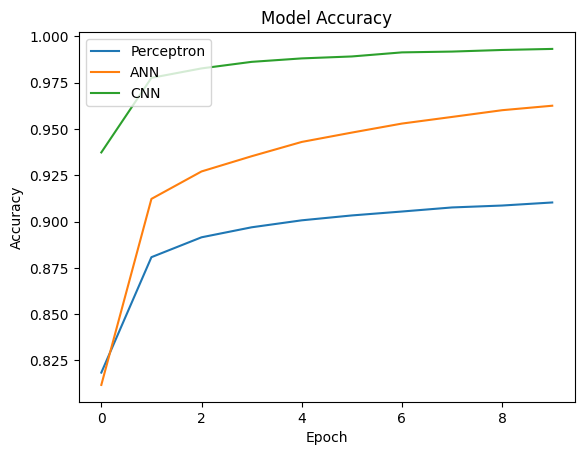

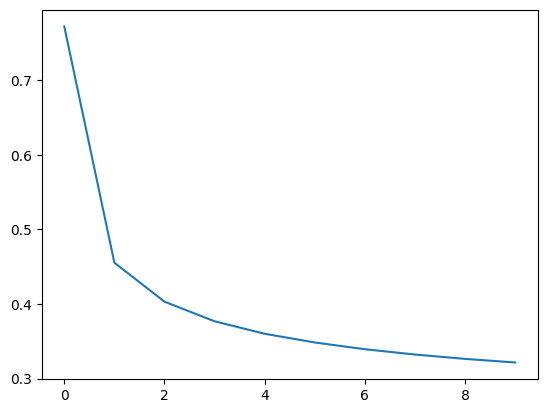

In [53]:
## side by side comparison 

print(f"Perceptron: {acc_perceptron}")
print(f"ANN: {acc_ann}")
print(f"CNN: {acc_cnn}")

## Comparision by visualization 

plt.plot(history_percp.history["accuracy"])
plt.plot(history_ann.history["accuracy"])
plt.plot(history_cnn.history["accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Perceptron", "ANN", "CNN"], loc="upper left")
plt.show()

plt.plot(history_percp.history["loss"])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


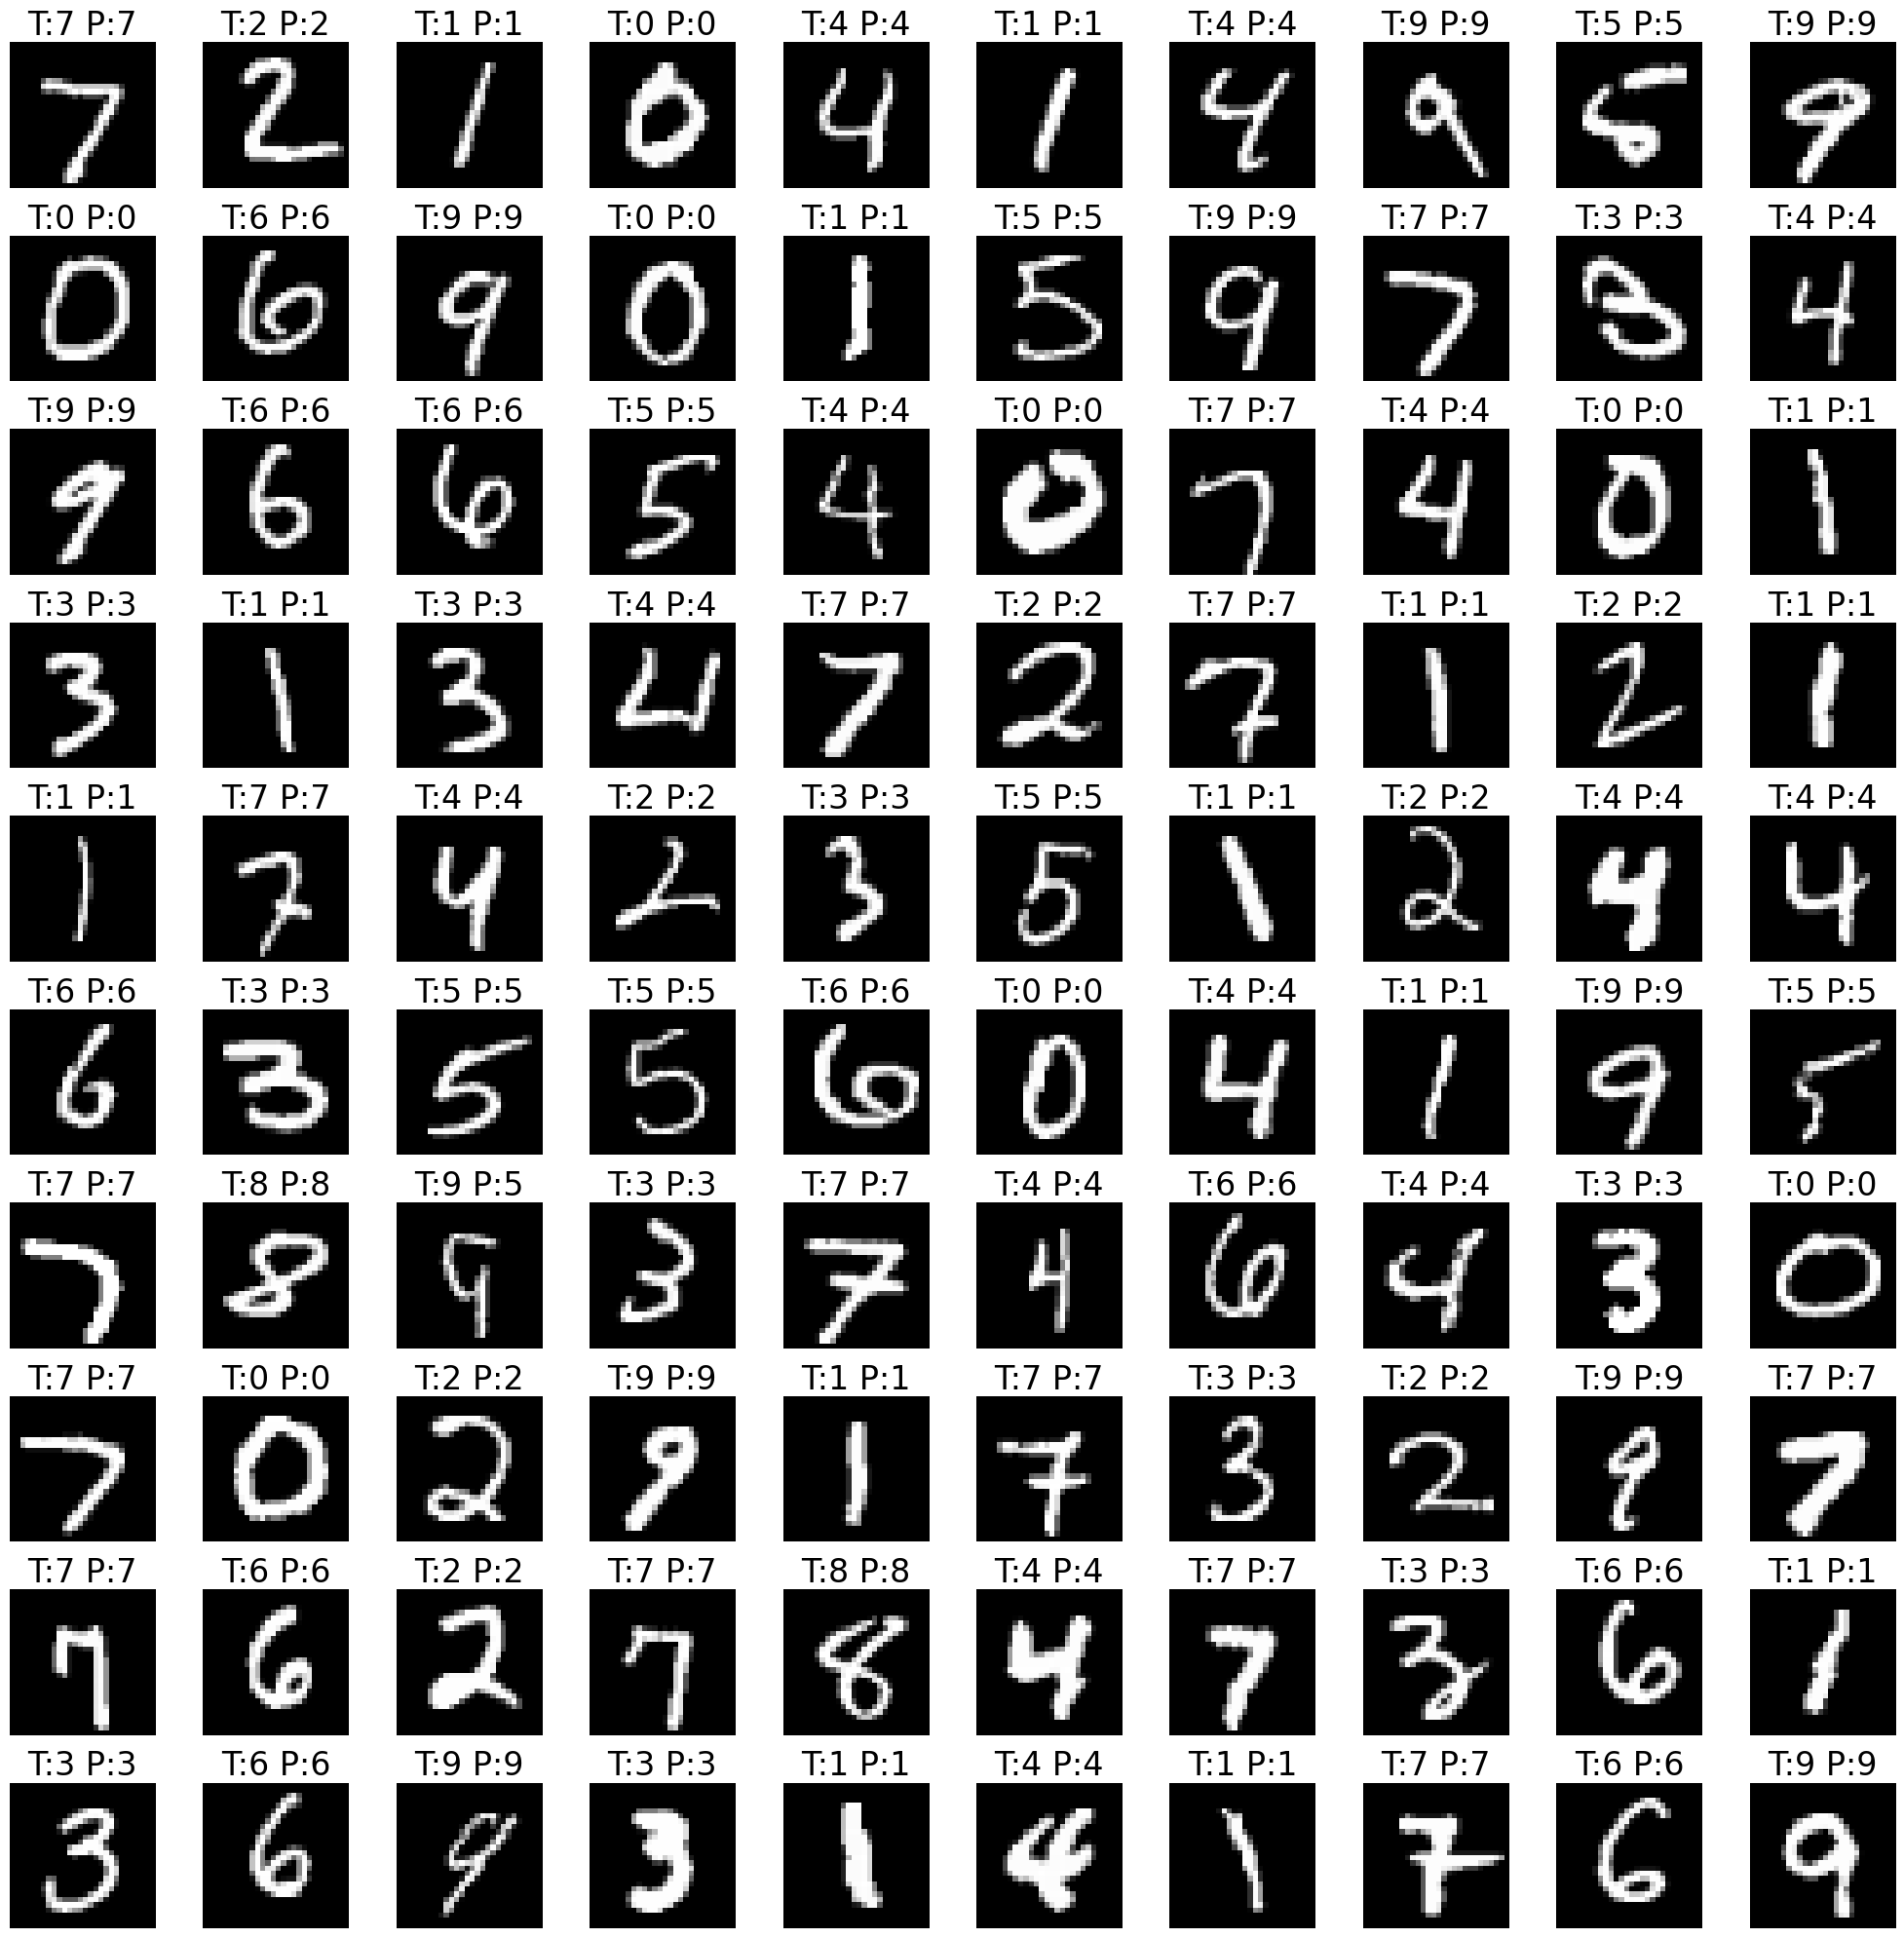

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Predict all at once (FAST)
y_pred = cnn.predict(X_test_cnn)

# Convert probabilities to labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(20, 20))

for i in range(100):

    plt.subplot(10, 10, i + 1)

    plt.imshow(X_test_cnn[i].reshape(28, 28), cmap="gray")

    plt.title(
        f"T:{y_true_labels[i]} P:{y_pred_labels[i]}",
        fontsize=24
    )

    plt.axis("off")

plt.tight_layout()
plt.show()